In [1]:
import pandas as pd

# load dataset
df = pd.read_csv('netflix_titles.csv')

# show first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [4]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [7]:
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,0
date_added,10
release_year,0
rating,0
duration,0


In [9]:
df = df.dropna(subset=['date_added'])

In [10]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2624
cast,825
country,0
date_added,0
release_year,0
rating,0
duration,0


In [11]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2666


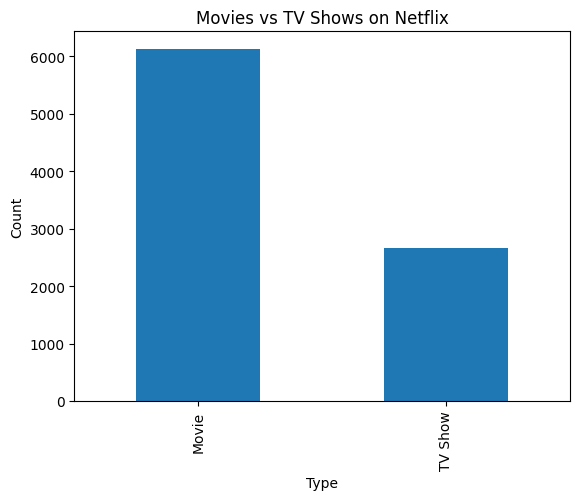

In [12]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar')
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [13]:
df['country'] = df['country'].str.split(', ')

In [14]:
df = df.explode('country')

In [15]:
df['country'].value_counts().head(10)

,count
country,
United States,3683
India,1046
Unknown,830
United Kingdom,803
Canada,445
France,393
Japan,317
Spain,232
South Korea,231


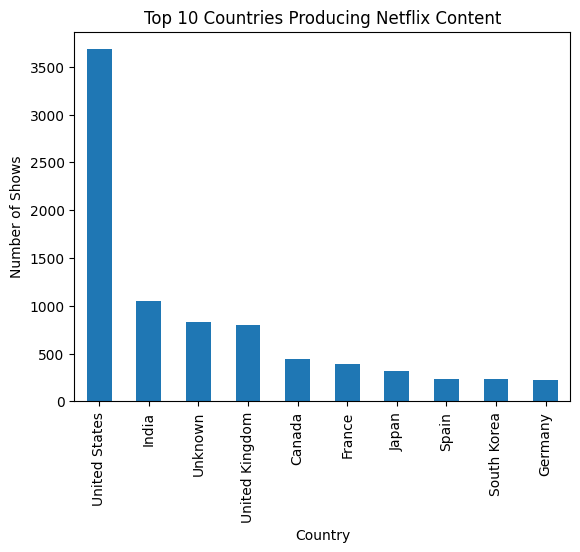

In [16]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Shows')
plt.show()

In [17]:
df_country = df[df['country'] != 'Unknown']

In [18]:
df_country['country'].value_counts().head(10)

,count
country,
United States,3683
India,1046
United Kingdom,803
Canada,445
France,393
Japan,317
Spain,232
South Korea,231
Germany,226


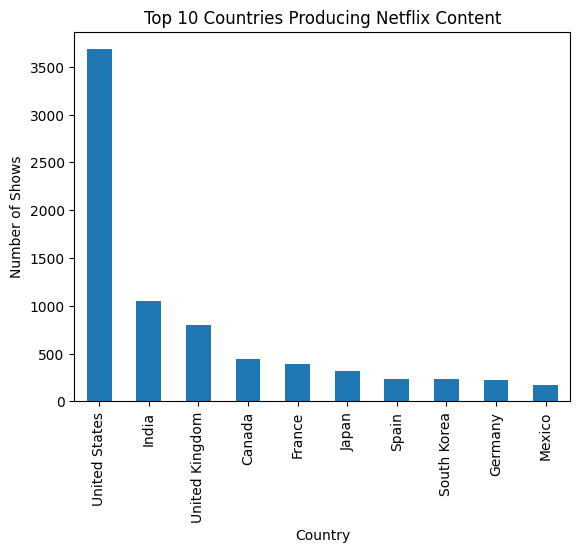

In [19]:
df_country['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Shows')
plt.show()

In [20]:
df['release_year'].value_counts().head()

,count
release_year,
2018,1389
2017,1276
2019,1208
2016,1154
2020,1054


In [21]:
year_counts = df['release_year'].value_counts().sort_index()
year_counts.head()

,count
release_year,
1925,1
1942,2
1943,3
1944,4
1945,4


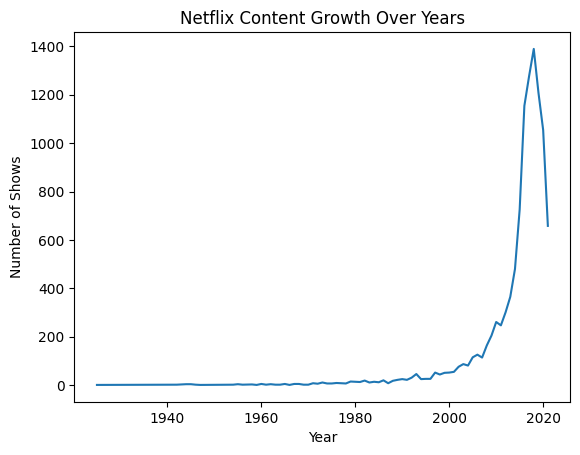

In [22]:
import matplotlib.pyplot as plt

year_counts.plot(kind='line')
plt.title('Netflix Content Growth Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Shows')
plt.show()

In [23]:
df['listed_in'] = df['listed_in'].str.split(', ')

In [24]:
df = df.explode('listed_in')

In [25]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
International Movies,3509
Dramas,3199
Comedies,1981
International TV Shows,1464
Action & Adventure,1182
Documentaries,1116
Independent Movies,1040
TV Dramas,851
Children & Family Movies,845


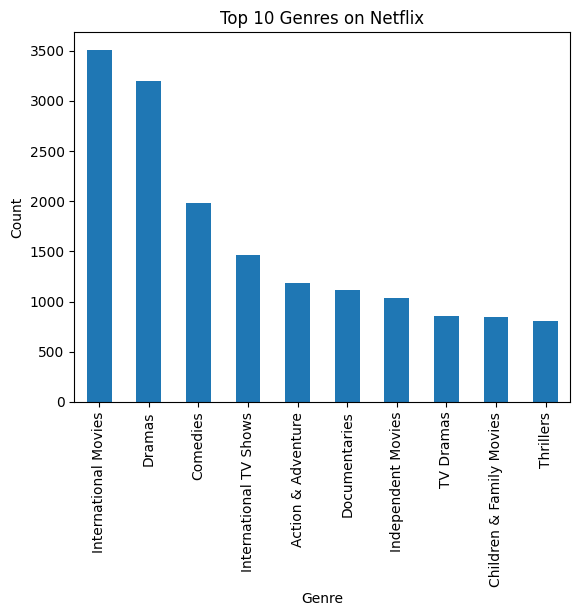

In [26]:
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()